# Model Evaluation

In [1]:
# ----------------------------
# IMPORT STATEMENTS
# ----------------------------
import os
import csv
import librosa

import numpy as np
import matplotlib.pyplot as plt

from scipy import signal
from scipy.io.wavfile import read
from IPython.display import Audio
from sklearn.model_selection import train_test_split

In [2]:
# ----------------------------
# CONSTANTS
# ----------------------------

HOP_LENGTH = 512
FRAME_LENGTH = 1024

In [3]:
# ----------------------------
# FUNCTION DEFINITIONS
# ----------------------------

def novelty(x, hop_length, frame_length):
    """Calculate the novelty function of an audio signal"""

    # Convert multi-channel audio to mono
    if len(x.shape) > 1:
        x = x.sum(axis=0)

    # Normalize audio signal
    x_norm = x / max(abs(x))

    # Calculate novelty function
    rmse = librosa.feature.rms(y=x_norm, frame_length=frame_length, hop_length=hop_length)
    rmse_diff = np.diff(rmse[0])
    novelty = np.concatenate((rmse_diff, np.array([0])))  # Add a zero at the end to maintain the same length
    novelty[novelty < 0] = 0  # We only care about increases in energy

    return novelty


def get_novelty(file):
    """Return the saved novelty array for a given audio file"""

    basename = os.path.basename(file)
    filename = basename.replace('.wav', '.npy')
    path = os.path.join(novelty_dir, filename)

    return np.load(path)


def get_ground_truth_beats(file):
    """Extract ground truth beat times for a given audio file"""

    # Get beat CSV path
    basename = os.path.basename(file)
    filename = basename.replace('.wav', '_beats.csv')
    path = os.path.join(beat_out, filename)

    onsets = []

    # Add each beat to an onset list
    with open(path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            onsets.append(float(row['beat_time']))

    return np.array(onsets)  # return as numpy array


def metrics(beats, ground_truth):
    """Evaluate the onset detection model with three different metrics, given the detected onsets, and ground truth onsets"""

    # Count TPs, FPs, and FNs
    tp = fp = fn = j = 0

    # Iterate over detected beats
    for i in range(len(beats)):
        # All ground truth beats before the start of the tolerance range are false negatives
        while j < len(ground_truth) and ground_truth[j] < beats[i] - 0.05:
            j += 1
            fn += 1

        # Only a true positive if the current ground truth value is within the threshold,
        if j < len(ground_truth) and ground_truth[j] <= beats[i] + 0.05:
            j += 1
            tp += 1
        # Otherwise there were no ground truth beats within the threshold, and this onset is a false positive
        else:
            fp += 1

        i += 1

    # All remaining ground truth beats were not detected, and are false negatives
    while j < len(ground_truth):
        fn += 1
        j += 1

    precision = tp / max(tp + fp, 1)  # no division by 0
    recall = tp / max(tp + fn, 1)  # no division by 0

    f1 = 2 * (precision * recall) / max(precision + recall, 1e-6)  # no division by 0

    return precision, recall, f1


def get_sample_rate(file):
    """Get the sample rate for a given audio file from the metadata table"""

    name = os.path.basename(file)
    meta_file = os.path.join(root, "metadata.csv")
    with open(meta_file, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row['file'] == name:
                return float(row['sample rate'])

    return None


def evaluate_tolerance(data, labels, tolerance):
    """Calculate the average f1 score across the training data for a single tolerance value"""

    total_f1 = 0

    for i in range(len(data)):
        fs, n = data[i]
        b = labels[i]

        frames=range(len(n))
        t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

        peaks, _ = signal.find_peaks(n, height=tolerance)
        p = t[peaks]

        _, _, f1 = metrics(p, b)

        total_f1 += f1

    return total_f1 / len(data)


def spectral_flux(x, hop_length, frame_length):
    """Calculate the spectral flux of an audio signal"""

    # Convert multi-channel audio to mono
    if len(x.shape) > 1:
        x = x.sum(axis=0)

    # Normalize audio signal
    x_norm = x / max(abs(x))

    # Calculate spectral flux
    stft = librosa.stft(x_norm, hop_length=hop_length, win_length=frame_length)
    diff = np.diff(np.abs(stft), axis=1)
    flux = np.sum(diff ** 2, axis=0)
    flux = np.concatenate(([0], flux))

    return flux / np.max(flux)  # normalize


def zero_crossing_rate(x, hop_length, frame_length):
    """Calculate the zero crossing rate of an audio signal"""

    # Convert multi-channel audio to mono
    if len(x.shape) > 1:
        x = x.sum(axis=0)

    # Normalize audio signal
    x_norm = x / max(abs(x))

    # Calculate zero crossing rate
    rate = librosa.feature.zero_crossing_rate(x_norm, hop_length=hop_length, frame_length=frame_length)
    diff_rate = np.diff(rate[0]) ** 2
    diff_rate = np.concatenate(([0], diff_rate))

    return diff_rate / np.max(diff_rate)  # normalize


def mfcc(x, hop_length, frame_length):
    """Calculate the MFCCs of an audio signal"""

    # Convert multi-channel audio to mono
    if len(x.shape) > 1:
        x = x.sum(axis=0)

    # Normalize audio signal
    x_norm = x / max(abs(x))

    # Calculate mfcc's
    mfccs = librosa.feature.mfcc(y=x_norm, sr=fs, hop_length=hop_length, win_length=frame_length)
    diff_mfcc = np.diff(mfccs, axis=1)
    diff_mfcc[diff_mfcc < 0] = 0
    diff_mfcc = np.concatenate((np.zeros((diff_mfcc.shape[0], 1)), diff_mfcc), axis=1)

    return diff_mfcc.T / np.max(diff_mfcc, axis=1)  # normalize


def get_sf(file):
    """Return the saved spectral flux array for a given audio file"""

    basename = os.path.basename(file)
    filename = basename.replace('.wav', '.npy')
    path = os.path.join(sf_dir, filename)

    return np.load(path)


def get_zcr(file):
    """Return the saved zero crossing rate array for a given audio file"""

    basename = os.path.basename(file)
    filename = basename.replace('.wav', '.npy')
    path = os.path.join(zcr_dir, filename)

    return np.load(path)


def get_mfcc(file):
    """Return the saved MFCC array for a given audio file"""

    basename = os.path.basename(file)
    filename = basename.replace('.wav', '.npy')
    path = os.path.join(mfcc_dir, filename)

    return np.load(path)


def evaluate(fs, features, weights):
    # Weighted sum of features
    n = np.dot(features, weights)
    ept, _ = signal.find_peaks(n, height=0.5)

    # Get peak times
    eframes = range(len(n))
    etf = librosa.frames_to_time(eframes, sr=fs, hop_length=HOP_LENGTH)

    epks = etf[ept]
    return epks


def evaluate_all(data, labels, weights):
    # Calculate average f1 score over all training data
    tot_f1 = 0

    for i in range(len(data)):
        b = evaluate(*data[i], weights)
        _, _, f1 = metrics(b, labels[i])

        tot_f1 += f1

    return tot_f1 / len(data)


def epoch(data, labels, w, delta, lr):
    # Evaluate original F1 Score
    base_f1 = evaluate_all(data, labels, w)
    grad = np.zeros_like(w)

    # Create gradient vector by testing each weight
    for i in range(len(grad)):
        new_weights = np.copy(w)
        new_weights[i] += delta

        new_f1 = evaluate_all(data, labels, new_weights)
        grad[i] = (new_f1 - base_f1) / delta

    # Return adjusted weights and epoch F1 score
    return w + lr * grad, base_f1

## Data & Preprocessing
The below cells only need to be run once to import all necessary packages, store all necessary data, and defi.

In [4]:
# Dataset should be placed within a data folder on the same level as this notebook
root = os.path.abspath('./data/ballroom')

# Ballroom dataset inner directories
audio_root = os.path.join(root, "BallroomData")
beats_root = os.path.join(root, "BallroomAnnotations", "ballroomBeats")
tempo_root = os.path.join(root, "BallroomAnnotations", "ballroomTempo")

In [5]:
audio_files = []

# Iterate through the style folders in the dataset
for style in os.listdir(audio_root):
    style_path = os.path.join(audio_root, style)

    if not os.path.isdir(style_path):
        continue

    # Add each audio file's path to the list
    for file in os.listdir(style_path):
        if not file.endswith(".wav"):
            continue

        path = os.path.join(style_path, file)
        audio_files.append(path)

In [6]:
# Create directories to store generated CSV files
beat_out = os.path.join(root, "beat_csv")
tempo_out = os.path.join(root, "tempo_csv")

os.makedirs(beat_out, exist_ok=True)
os.makedirs(tempo_out, exist_ok=True)

In [7]:
# Generate and save beat/tempo csvs
curr = 1

# Iterate through all audio files
for file in audio_files:
    filename = os.path.basename(file)
    base = filename.replace(".wav", "")

    bpm_path = os.path.join(tempo_root, base + ".bpm")
    beats_path = os.path.join(beats_root, base + ".beats")

    print(f'File {curr}/{len(audio_files)} - {filename}:')

    # -------------------------
    # TEMPO CSV
    # -------------------------
    if os.path.exists(bpm_path):
        with open(bpm_path) as f:
            bpm = float(f.read().strip())

        tempo_file = os.path.join(tempo_out, base + "_tempo.csv")

        with open(tempo_file, "w", newline="") as f:

            writer = csv.DictWriter(
                f,
                fieldnames=["file", "style", "tempo_bpm"]
            )

            writer.writeheader()
            writer.writerow({
                "file": file,
                "style": style,
                "tempo_bpm": bpm
            })

        print(f'\tTempo CSV - {tempo_file}')

    # -------------------------
    # BEAT CSV
    # -------------------------
    if os.path.exists(beats_path):
        beat_rows = []

        with open(beats_path) as f:

            for line in f:

                parts = line.strip().split()

                beat_time = float(parts[0])
                beat_id = int(parts[1])

                beat_rows.append({
                    "file": file,
                    "style": style,
                    "beat_time": beat_time,
                    "beat_id": beat_id
                })

        beat_file = os.path.join(beat_out, base + "_beats.csv")

        with open(beat_file, "w", newline="") as f:

            writer = csv.DictWriter(
                f,
                fieldnames=["file", "style", "beat_time", "beat_id"]
            )

            writer.writeheader()
            writer.writerows(beat_rows)

        print(f'\tBeat CSV - {beat_file}')

    curr += 1

print("\nPer-file beat and tempo CSVs created.")

	Tempo CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/tempo_csv/Media-104314_tempo.csv
	Beat CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/beat_csv/Media-104314_beats.csv
File 553/698 - Media-100614.wav:
	Tempo CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/tempo_csv/Media-100614_tempo.csv
	Beat CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/beat_csv/Media-100614_beats.csv
File 554/698 - Albums-Chrisanne2-12.wav:
	Tempo CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/tempo_csv/Albums-Chrisanne2-12_tempo.csv
	Beat CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/beat_csv/Albums-Chrisanne2-12_beats.csv
File 555/698 - Media-100616.wav:
	Tempo CSV - /Users/aidan

In [8]:
meta_rows = []
for file in audio_files:
    dirname, filename = os.path.split(file)
    (sample_rate, x) = read(file)

    length = x.shape[-1] / sample_rate
    style = dirname.strip('/').split('/')[-1]

    meta_rows.append({
        "file": filename,
        "directory": dirname,
        "style": style,
        "sample rate": sample_rate,
        "length": length
    })

meta_file = os.path.join(root, "metadata.csv")
with open(meta_file, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["file", "directory", "style", "sample rate", "length"]
    )

    writer.writeheader()
    writer.writerows(meta_rows)

print(f'Metadata CSV written at {meta_file}.')

Metadata CSV written at /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/metadata.csv.


In [9]:
# Make directory for novelty functions
novelty_dir = os.path.join(root, 'novelty')
os.makedirs(novelty_dir, exist_ok=True)

In [10]:
# Save novelty functions to novelty dir
done = 0
for file in audio_files:
    basename = os.path.basename(file)
    (fs, x) = read(file)
    n = novelty(x, HOP_LENGTH, FRAME_LENGTH)

    filename = basename.replace(".wav", ".npy")
    with open(os.path.join(novelty_dir, filename), 'wb') as f:
        np.save(f, n)

    done += 1
    print(f'[{done}/{len(audio_files)}] Completed file "{basename}" - novelty saved as "{filename}"', flush=True)

[698/698] Completed file "Albums-Latin_Jam3-07.wav" - novelty saved as "Albums-Latin_Jam3-07.npy"


In [11]:
# Make directories for new features
sf_dir = os.path.join(root, 'spectral_flux')
zcr_dir = os.path.join(root, 'zero_crossing_rate')
mfcc_dir = os.path.join(root, 'mfcc_flux')

os.makedirs(sf_dir, exist_ok=True)
os.makedirs(zcr_dir, exist_ok=True)
os.makedirs(mfcc_dir, exist_ok=True)

In [12]:
# Store other features in their respective directories
done = 0
for file in audio_files:
    basename = os.path.basename(file)
    (fs, x) = read(file)
    flux = spectral_flux(x, HOP_LENGTH, FRAME_LENGTH)
    zcr = zero_crossing_rate(x, HOP_LENGTH, FRAME_LENGTH)
    mfccs = mfcc(x, HOP_LENGTH, FRAME_LENGTH)

    filename = basename.replace(".wav", ".npy")

    with open(os.path.join(sf_dir, filename), 'wb') as f:
        np.save(f, flux)
    with open(os.path.join(zcr_dir, filename), 'wb') as f:
        np.save(f, zcr)
    with open(os.path.join(mfcc_dir, filename), 'wb') as f:
        np.save(f, mfccs)

    done += 1
    print(f'[{done}/{len(audio_files)}] Completed file "{basename}" - features saved as "{filename}"', flush=True)

[698/698] Completed file "Albums-Latin_Jam3-07.wav" - features saved as "Albums-Latin_Jam3-07.npy"


## Dataset
To avoid using training data in our metrics, we will perform the same train-test split on the dataset that was used in training, and only use testing data throughout the rest of this notebook.

In [16]:
data = []
labels = []

# Consolidate features functions and ground truth beats into lists
for file in audio_files:
    fs = get_sample_rate(file)

    n = get_novelty(file)
    sf = get_sf(file)
    mfcc = get_mfcc(file)

    feats = np.stack([n, sf, mfcc[:, 0]], axis=1)
    b = get_ground_truth_beats(file)

    data.append((fs, feats))
    labels.append(b)

# Split testing and training data
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, test_size=0.2, random_state=42)

## Baseline Model

The baseline model simply uses an RMSE novelty function, and picks peaks to determine onsets based on that function. For the baseline model, we optimized the tolerance value on training data using gradient ascent on the F1 score to achieve the best possible accuracy.

### Pre-optimization
Before optimization, we simply picked a tolerance value by looking at one of the novelty functions. This value was 0.03.

In [40]:
pre_p = pre_r = pre_f1 = 0

# Calculate average percision, recall, and F1 score across TESTING data
for i in range(len(test_data)):
    fs, feats = test_data[i]
    n = feats[:, 0]
    b = test_labels[i]

    frames=range(len(n))
    t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

    peaks, _ = signal.find_peaks(n, height=0.03)
    pt = t[peaks]

    p, r, f1 = metrics(pt, b)

    pre_p += p
    pre_r += r
    pre_f1 += f1

pre_p /= len(test_data)
pre_r /= len(test_data)
pre_f1 /= len(test_data)

print(f'Average Precision: {pre_p:.2%}')
print(f'Average Recall: {pre_r:.2%}')
print(f'Average F1 Score: {pre_f1:.4f}')

Average Precision: 36.71%
Average Recall: 66.86%
Average F1 Score: 0.4498


### Post-optimization
Gradient ascent determined the optimal threshold value to be 0.03729. Using this value we get the following metrics:

In [41]:
post_p = post_r = post_f1 = 0

# Calculate average percision, recall, and F1 score across TESTING data
for i in range(len(test_data)):
    fs, feats = test_data[i]
    n = feats[:, 0]
    b = test_labels[i]

    frames=range(len(n))
    t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

    peaks, _ = signal.find_peaks(n, height=0.03729)
    pt = t[peaks]

    p, r, f1 = metrics(pt, b)

    post_p += p
    post_r += r
    post_f1 += f1

post_p /= len(test_data)
post_r /= len(test_data)
post_f1 /= len(test_data)

print(f'Average Precision: {post_p:.2%}')
print(f'Average Recall: {post_r:.2%}')
print(f'Average F1 Score: {post_f1:.2%}')

Average Precision: 42.51%
Average Recall: 60.45%
Average F1 Score: 46.72%


Comparing the two models we have:

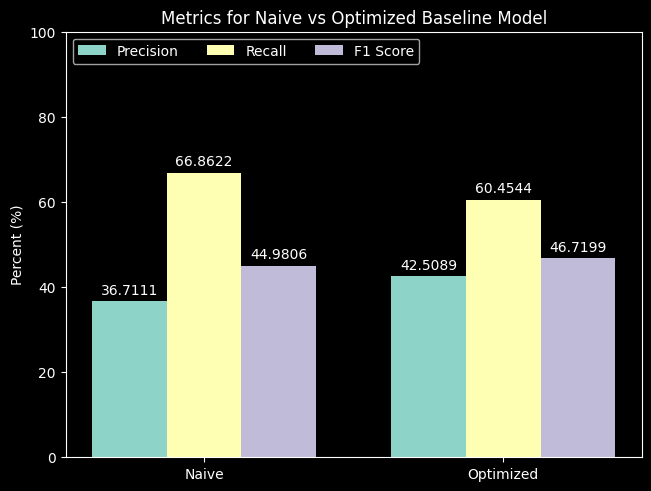

In [42]:
percent_p_base = np.array([pre_p, post_p]) * 100
percent_r_base = np.array([pre_r, post_r]) * 100
percent_f1_base = np.array([pre_f1, post_f1]) * 100

x = np.arange(2)  # the label locations

fig, ax = plt.subplots(layout='constrained')

p_rects = ax.bar(x, percent_p_base, 0.25, label='Precision')
ax.bar_label(p_rects, padding=3)

r_rects = ax.bar(x + 0.25, percent_r_base, 0.25, label='Recall')
ax.bar_label(r_rects, padding=3)

f1_rects = ax.bar(x + 0.5, percent_f1_base, 0.25, label='F1 Score')
ax.bar_label(f1_rects, padding=3)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Percent (%)')
ax.set_title('Metrics for Naive vs Optimized Baseline Model')
ax.set_xticks(x + 0.25, ('Naive', 'Optimized'))
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 100)

We can see that the optimized model displays an increase in precision, but a decrease in recall. However, the overall F1 score still increases. This means that the optimizations decreased the model's sensitivity, which resulted in less of the onsets being identified, but reduced the amound of false positives along with it, increasing the overall score.

## Improved Model
The improved model works similarly, but combines multiple features in place of a single-feature novelty function. The features used are RMSE (the original novelty function), Spectral Flux, and the 0th Mel Frequency Cepstral Coefficient. These features were chosen through an extensive selection process, detailed in index.ipynb. This naive model simply added the functions for the three factors, and used a fixed threshold value of 0.5. The optimized model instead took a *weighted* sum of the features, and picked peaks using the same fixed threshold (weighting eliminated the need for a variable threshold). The weights were optimized through experimentation, as well as multi-variate gradient ascent on the F1 score.

### Pre-optimization
When simply adding the functions together, the model performs as follows:

In [43]:
pre_p = pre_r = pre_f1 = 0

# Calculate average percision, recall, and F1 score across TESTING data
for i in range(len(test_data)):
    fs, feats = test_data[i]
    n = feats.sum(axis=1)
    b = test_labels[i]

    frames=range(len(n))
    t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

    peaks, _ = signal.find_peaks(n, height=0.5)
    pt = t[peaks]

    p, r, f1 = metrics(pt, b)

    pre_p += p
    pre_r += r
    pre_f1 += f1

pre_p /= len(test_data)
pre_r /= len(test_data)
pre_f1 /= len(test_data)

print(f'Average Precision: {pre_p:.2%}')
print(f'Average Recall: {pre_r:.2%}')
print(f'Average F1 Score: {pre_f1:.4f}')

Average Precision: 51.41%
Average Recall: 47.88%
Average F1 Score: 0.4598


### Post-optimization
The original trial and error process determined that the weights (1.4, 1, 1.4) for RMSE, Spectral Flux, and MFCC 0, respectively, were the optimal starting point. Gradient descent further optimized these weights to (1.59518808, 0.89276187, 1.62964896). These optimized weights acheive the following metrics:

In [44]:
weights = np.array([1.59518808, 0.89276187, 1.62964896])
post_p = post_r = post_f1 = 0

# Calculate average percision, recall, and F1 score across TESTING data
for i in range(len(test_data)):
    fs, feats = test_data[i]
    n = np.dot(feats, weights)
    b = test_labels[i]

    frames=range(len(n))
    t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

    peaks, _ = signal.find_peaks(n, height=0.5)
    pt = t[peaks]

    p, r, f1 = metrics(pt, b)

    post_p += p
    post_r += r
    post_f1 += f1

post_p /= len(test_data)
post_r /= len(test_data)
post_f1 /= len(test_data)

print(f'Average Precision: {post_p:.2%}')
print(f'Average Recall: {post_r:.2%}')
print(f'Average F1 Score: {post_f1:.2%}')

Average Precision: 47.06%
Average Recall: 63.21%
Average F1 Score: 50.43%


Comparing our naive and optimized improved models, we have:

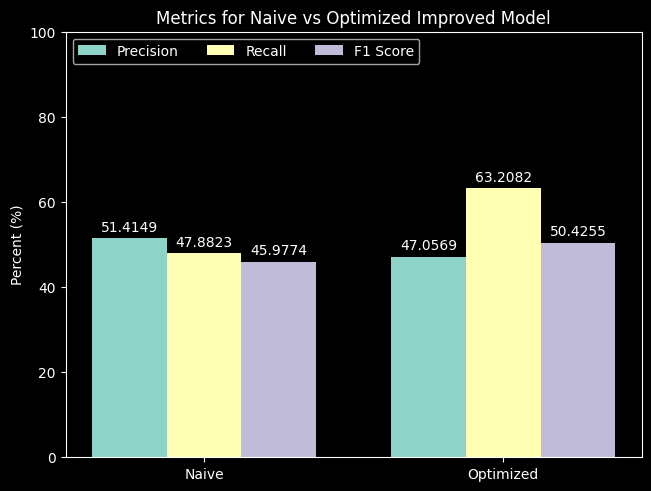

In [46]:
percent_p_imp = np.array([pre_p, post_p]) * 100
percent_r_imp = np.array([pre_r, post_r]) * 100
percent_f1_imp = np.array([pre_f1, post_f1]) * 100

x = np.arange(2)  # the label locations

fig, ax = plt.subplots(layout='constrained')

p_rects = ax.bar(x, percent_p_imp, 0.25, label='Precision')
ax.bar_label(p_rects, padding=3)

r_rects = ax.bar(x + 0.25, percent_r_imp, 0.25, label='Recall')
ax.bar_label(r_rects, padding=3)

f1_rects = ax.bar(x + 0.5, percent_f1_imp, 0.25, label='F1 Score')
ax.bar_label(f1_rects, padding=3)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Percent (%)')
ax.set_title('Metrics for Naive vs Optimized Improved Model')
ax.set_xticks(x + 0.25, ('Naive', 'Optimized'))
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 100)

Here we can see the opposite scenario to our baseline model. Our precision decreased a bit from the naive model after optimizations, but the recall improved greatly. This increased the overall F1 score by nearly 5%. In this case, the overall sensitivity of the model was increased, leading to more of the actual onsets being detected, but also slightly more false positives.

## Baseline vs. Improved Model Evaluation
Now, we can finally compare our baseline model with our improved model.

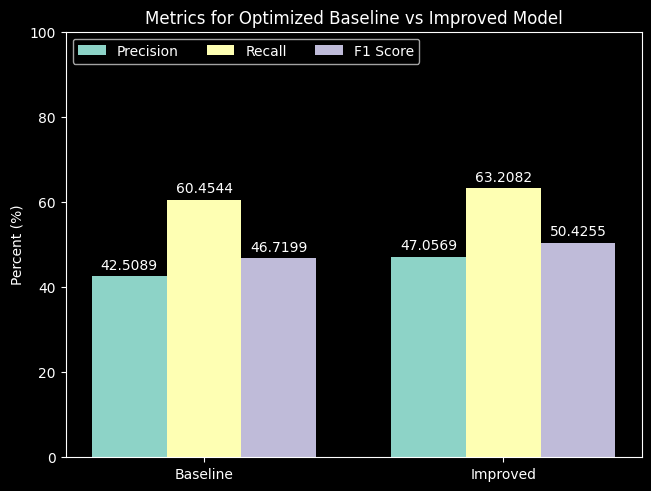

In [49]:
percent_p = np.stack([percent_p_base, percent_p_imp])[:, 1]
percent_r = np.stack([percent_r_base, percent_r_imp])[:, 1]
percent_f1 = np.stack([percent_f1_base, percent_f1_imp])[:, 1]

x = np.arange(2)  # the label locations

fig, ax = plt.subplots(layout='constrained')

p_rects = ax.bar(x, percent_p, 0.25, label='Precision')
ax.bar_label(p_rects, padding=3)

r_rects = ax.bar(x + 0.25, percent_r, 0.25, label='Recall')
ax.bar_label(r_rects, padding=3)

f1_rects = ax.bar(x + 0.5, percent_f1, 0.25, label='F1 Score')
ax.bar_label(f1_rects, padding=3)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Percent (%)')
ax.set_title('Metrics for Optimized Baseline vs Improved Model')
ax.set_xticks(x + 0.25, ('Baseline', 'Improved'))
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 100)

And in this case, we can see an improvement in all three statistics! This is because while our model optimizations involved an optimization of the model's overall sensitivity, which typically causes a tradeoff between a model's precision and accuracy. But since our improved model takes a different approach entirely, in the optimized versions of both models, we don't see that tradeoff at all, and rather an improvement in all three metrics!